# PCA Manifold of Tuning Curves

This notebook studies the low-dimensional structure of neural population tuning curves via PCA:

1. **PCA on tuning curves** — fit PCA on the (360 angular bins × N neurons) tuning-curve matrix and visualise the ring manifold in PC space
2. **Variance explained** — scree plots showing how many PCs capture the population structure
3. **Firing-rate projections** — project time-resolved firing rates onto the tuning-curve PCs to see moment-by-moment trajectories in 3-D
4. **Group-level summary** — compare variance-explained profiles across genotype × age groups
5. **Gallery** — PCA rings across subjects, one per group

In [32]:
# --- Setup ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
from sklearn.decomposition import PCA

from remapping.dataset import (
    MiceDataset, Animals, GROUP_ORDER,
    EXPERIMENT_ORDER, SESSION_TYPE_MAP,
    EXPERIMENT_TYPE_ORDER, EXPERIMENT_TYPE_COLORS,
)
from remapping.processing import smooth_tuning_curves_circularly
from remapping.plotting import BehaviorColors, PlotStyle, get_figures_path

mice = MiceDataset()
colors = BehaviorColors()
style = PlotStyle()
palette = mice.get_group_palette()

In [33]:
# --- Parameters ---

# Processing pipeline
ONLY_MOVING = True
BINS_COMPRESS = 3
BINS_SMOOTHING = 3
BINS_PHI = 360
TC_KERNEL = 20           # circular smoothing kernel for tuning curves

# PCA
N_COMPONENTS = 10        # max PCs to retain for scree plots
N_PLOT_PCS = 3           # PCs shown in ring / trajectory plots

# Angular-position colourmap
PHI_CMAP = colors.angular_position

# Figure output
fig_path = get_figures_path("1.embeddings", "00_pca_manifold")

## 1 — Example recording: PCA on tuning curves

In [34]:
# Pick an example subject / recording
subject = Animals.M62
fov = mice.get_available_fovs(subject)[0]
session = mice.get_available_sessions(subject, fov)[0]
runs = mice.get_available_runs(subject, fov, session)
run = runs[0]

info = mice.get_subject_info(subject)
print(f"Subject: {subject.value}  |  FOV: {fov}  |  Session: {session}  |  Run: {run}")
print(f"Group: {info['genotype']} {info['age']}")
print(f"Available runs in this session: {runs}")

Subject: m62  |  FOV: 2  |  Session: fam1fam2  |  Run: fam1
Group: WT old
Available runs in this session: ['fam1', 'fam2']


In [35]:
# Load firing rates + tuning curves
firing_rates, phi, time, (cell_ids, _), tc_raw, phi_bins = mice.load_firing_rates(
    subject, fov, session, run,
    only_moving=ONLY_MOVING,
    bins_compress=BINS_COMPRESS,
    bins_smoothing=BINS_SMOOTHING,
    bins_phi=BINS_PHI,
)
tc = smooth_tuning_curves_circularly(tc_raw, kernel_size=TC_KERNEL)

n_bins, n_neurons = tc.shape
print(f"Tuning curves: {n_bins} angular bins × {n_neurons} neurons")
print(f"Firing rates:  {firing_rates.shape[0]} time bins × {n_neurons} neurons")

Tuning curves: 360 angular bins × 292 neurons
Firing rates:  4719 time bins × 292 neurons


In [36]:
# Fit PCA on the tuning-curve matrix (angular-bins × neurons)
pca = PCA(n_components=min(N_COMPONENTS, n_neurons, n_bins))
tc_pca = pca.fit_transform(tc)  # (n_bins, n_components)

print(f"Variance explained by first {N_PLOT_PCS} PCs: "
      f"{pca.explained_variance_ratio_[:N_PLOT_PCS].sum():.1%}")

Variance explained by first 3 PCs: 78.6%


### 1a — Scree plot (variance explained)

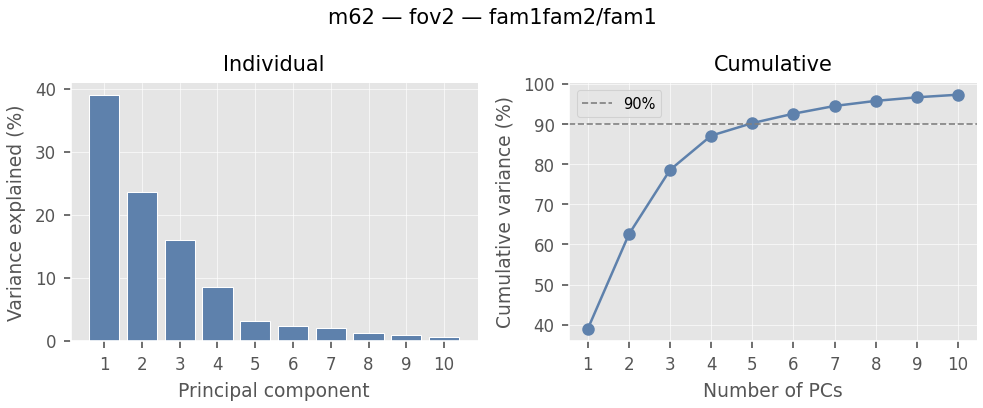

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(PlotStyle.FULL_WIDTH, 2.8))

n_pcs = len(pca.explained_variance_ratio_)
x = np.arange(1, n_pcs + 1)

# Individual variance
axes[0].bar(x, pca.explained_variance_ratio_ * 100, color="#5e81ac", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Individual")
axes[0].set_xticks(x)

# Cumulative variance
axes[1].plot(x, np.cumsum(pca.explained_variance_ratio_) * 100,
             "o-", color="#5e81ac", markersize=5)
axes[1].axhline(90, ls="--", color="grey", lw=0.8, label="90%")
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative variance (%)")
axes[1].set_title("Cumulative")
axes[1].set_xticks(x)
axes[1].legend(fontsize=7)

fig.suptitle(f"{subject.value} — fov{fov} — {session}/{run}", fontsize=10)
plt.tight_layout()
fig.savefig(fig_path / "scree_plot_example.pdf")
plt.show()

### 1b — Tuning-curve ring in PC1–PC2–PC3 space

In [38]:
def plot_ring_2d_3d(tc_pca, phi_bins, cmap, title="", fig_path=None, fname=None):
    """Plot the PCA ring in 2-D (PC1 vs PC2) and 3-D (PC1–PC2–PC3)."""
    norm = plt.Normalize(0, 360)
    c = cmap(norm(phi_bins))

    fig = plt.figure(figsize=(PlotStyle.FULL_WIDTH, 3.2))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.35)

    # --- 2-D ring ---
    ax2d = fig.add_subplot(gs[0, 0])
    # Close the ring by appending the first point
    pts = np.vstack([tc_pca[:, :2], tc_pca[:1, :2]])
    segments = np.stack([pts[:-1], pts[1:]], axis=1)
    lc = LineCollection(segments, colors=c, linewidths=1.8)
    ax2d.add_collection(lc)
    ax2d.scatter(tc_pca[:, 0], tc_pca[:, 1], c=phi_bins, cmap=cmap,
                 s=8, zorder=3, edgecolors="none")
    ax2d.set_xlabel("PC 1")
    ax2d.set_ylabel("PC 2")
    ax2d.set_title("PC1 vs PC2")
    ax2d.set_aspect("equal", adjustable="datalim")
    ax2d.autoscale_view()

    # --- 3-D ring ---
    ax3d = fig.add_subplot(gs[0, 1], projection="3d")
    for i in range(len(phi_bins) - 1):
        ax3d.plot(tc_pca[i:i+2, 0], tc_pca[i:i+2, 1], tc_pca[i:i+2, 2],
                  color=c[i], linewidth=1.5)
    # Close ring
    ax3d.plot([tc_pca[-1, 0], tc_pca[0, 0]],
              [tc_pca[-1, 1], tc_pca[0, 1]],
              [tc_pca[-1, 2], tc_pca[0, 2]], color=c[-1], linewidth=1.5)
    ax3d.scatter(tc_pca[:, 0], tc_pca[:, 1], tc_pca[:, 2],
                 c=phi_bins, cmap=cmap, s=6, depthshade=False)
    ax3d.set_xlabel("PC 1", fontsize=7, labelpad=2)
    ax3d.set_ylabel("PC 2", fontsize=7, labelpad=2)
    ax3d.set_zlabel("PC 3", fontsize=7, labelpad=2)
    ax3d.tick_params(labelsize=6)
    ax3d.set_title("PC1–PC2–PC3")

    # Colourbar in its own thin axis on the right
    cax = fig.add_subplot(gs[0, 2])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Angular position (°)", fontsize=8)

    if title:
        fig.suptitle(title, fontsize=10)
    fig.subplots_adjust(top=0.85)
    if fig_path and fname:
        fig.savefig(fig_path / fname)
    plt.show()
    return fig

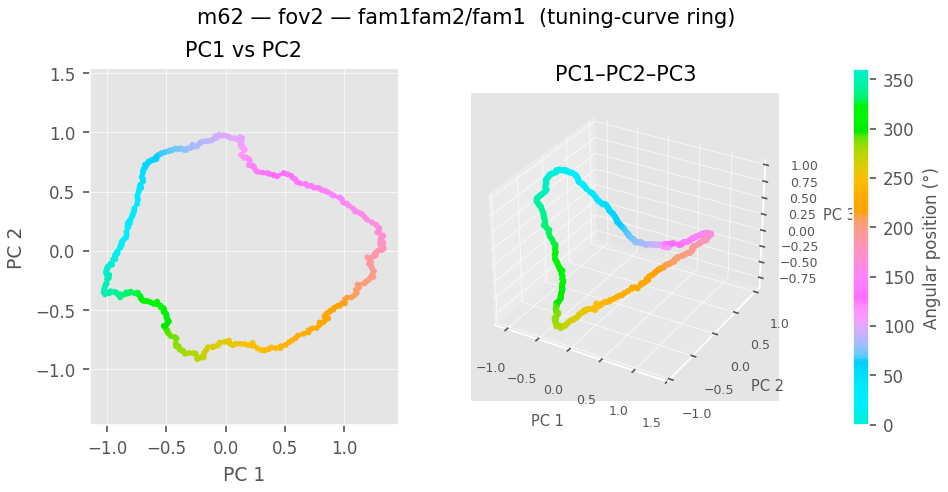

In [39]:
plot_ring_2d_3d(
    tc_pca, phi_bins, PHI_CMAP,
    title=f"{subject.value} — fov{fov} — {session}/{run}  (tuning-curve ring)",
    fig_path=fig_path, fname="ring_tuning_curves_example.pdf",
);

## 2 — Firing-rate trajectories projected onto the tuning-curve PCA

In [40]:
# Project time-resolved firing rates into the same PC space
fr_pca = firing_rates @ pca.components_[:N_PLOT_PCS].T  # (T, 3)

print(f"Projected firing rates: {fr_pca.shape}")

Projected firing rates: (4719, 3)


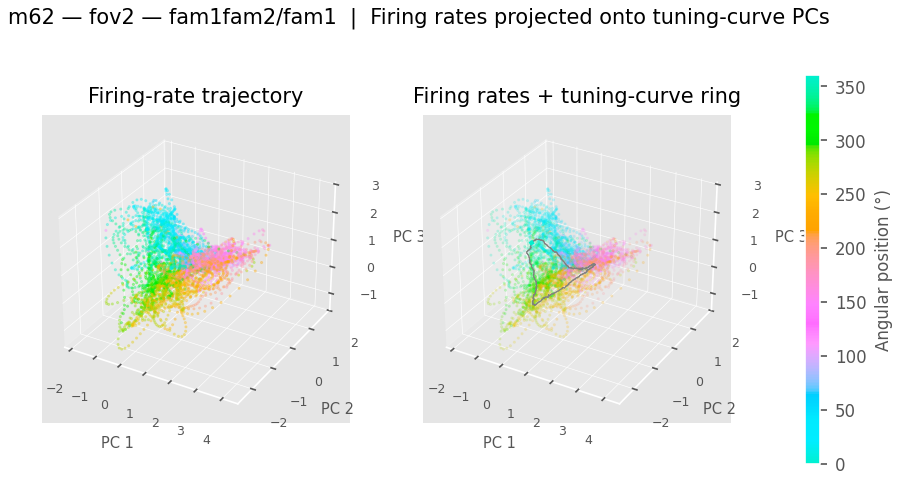

In [41]:
norm = plt.Normalize(0, 360)

fig = plt.figure(figsize=(PlotStyle.FULL_WIDTH, 3.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.35)

# --- 3-D: raw firing-rate trajectory ---
ax1 = fig.add_subplot(gs[0, 0], projection="3d")
ax1.scatter(fr_pca[:, 0], fr_pca[:, 1], fr_pca[:, 2],
            c=phi, cmap=PHI_CMAP, s=1, alpha=0.3, depthshade=False, rasterized=True)
ax1.set_xlabel("PC 1", fontsize=7, labelpad=2)
ax1.set_ylabel("PC 2", fontsize=7, labelpad=2)
ax1.set_zlabel("PC 3", fontsize=7, labelpad=2)
ax1.tick_params(labelsize=6)
ax1.set_title("Firing-rate trajectory")

# --- 3-D: tuning-curve ring overlaid on firing-rate cloud ---
ax2 = fig.add_subplot(gs[0, 1], projection="3d")
ax2.scatter(fr_pca[:, 0], fr_pca[:, 1], fr_pca[:, 2],
            c=phi, cmap=PHI_CMAP, s=1, alpha=0.15, depthshade=False, rasterized=True)
# Overlay tuning-curve ring
c_ring = PHI_CMAP(norm(phi_bins))
for i in range(len(phi_bins) - 1):
    ax2.plot(tc_pca[i:i+2, 0], tc_pca[i:i+2, 1], tc_pca[i:i+2, 2],
             color="grey", linewidth=0.5)
ax2.plot([tc_pca[-1, 0], tc_pca[0, 0]],
         [tc_pca[-1, 1], tc_pca[0, 1]],
         [tc_pca[-1, 2], tc_pca[0, 2]], color=c_ring[-1], linewidth=2.0)
ax2.set_xlabel("PC 1", fontsize=7, labelpad=2)
ax2.set_ylabel("PC 2", fontsize=7, labelpad=2)
ax2.set_zlabel("PC 3", fontsize=7, labelpad=2)
ax2.tick_params(labelsize=6)
ax2.set_title("Firing rates + tuning-curve ring")

# Colourbar
cax = fig.add_subplot(gs[0, 2])
sm = plt.cm.ScalarMappable(cmap=PHI_CMAP, norm=norm)
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Angular position (°)", fontsize=8)

fig.suptitle(
    f"{subject.value} — fov{fov} — {session}/{run}  |  "
    f"Firing rates projected onto tuning-curve PCs",
    fontsize=10,
)
fig.subplots_adjust(top=0.85)
fig.savefig(fig_path / "firing_rate_projections_example.pdf")
plt.show()

## 3 — Group-level variance-explained profiles

For each recording (subject × FOV × session × run), fit PCA on tuning curves and collect the cumulative variance explained. Then compare across genotype × age groups.

In [42]:
# Collect variance-explained profiles across all recordings
MAX_PCS = 10
records = []

for subject in mice.get_all_subjects():
    info = mice.get_subject_info(subject)
    group = f"{info['genotype']}_{info['age']}"
    for fov_i in mice.get_available_fovs(subject):
        for sess_i in mice.get_available_sessions(subject, fov_i):
            for run_i in mice.get_available_runs(subject, fov_i, sess_i):
                _, _, _, _, tc_raw_i, _ = mice.load_firing_rates(
                    subject, fov_i, sess_i, run_i,
                    only_moving=ONLY_MOVING,
                    bins_compress=BINS_COMPRESS,
                    bins_smoothing=BINS_SMOOTHING,
                    bins_phi=BINS_PHI,
                )
                tc_i = smooth_tuning_curves_circularly(tc_raw_i, kernel_size=TC_KERNEL)
                n_comp = min(MAX_PCS, tc_i.shape[0], tc_i.shape[1])
                pca_i = PCA(n_components=n_comp).fit(tc_i)
                var_ratio = pca_i.explained_variance_ratio_

                # Pad to MAX_PCS if fewer components
                padded = np.zeros(MAX_PCS)
                padded[:len(var_ratio)] = var_ratio

                records.append({
                    "subject": subject.value,
                    "fov": fov_i,
                    "session": sess_i,
                    "run": run_i,
                    "group": group,
                    "exp_type": SESSION_TYPE_MAP.get(sess_i, "other"),
                    "var_explained": padded,
                    "cumvar_3": np.cumsum(padded[:3])[-1],
                    "n_neurons": tc_i.shape[1],
                })

print(f"\nCollected {len(records)} recordings")


Collected 321 recordings


In [43]:
import pandas as pd

df = pd.DataFrame(records)
df.head()

,subject,fov,session,run,group,exp_type,var_explained,cumvar_3,n_neurons
0,m62,2,fam1fam2,fam1,WT_old,fam1 → fam2,"[0.3896879691009816, 0.2358085411782341, 0.160...",0.785804,292
1,m62,2,fam1fam2,fam2,WT_old,fam1 → fam2,"[0.36726126265339404, 0.3205433803329313, 0.10...",0.797604,292
2,m62,2,fam1nov,fam1,WT_old,fam1 → novel,"[0.41080916285379165, 0.2939972577859508, 0.12...",0.833002,247
3,m62,2,fam1nov,nov,WT_old,fam1 → novel,"[0.5522515560993564, 0.22612835016876626, 0.06...",0.844164,247
4,m62,2,fam1fam1rev,fam1,WT_old,fam1 → reversed,"[0.42406216501948624, 0.2707831003693922, 0.12...",0.824627,232


### 3a — Cumulative variance in first 3 PCs by group

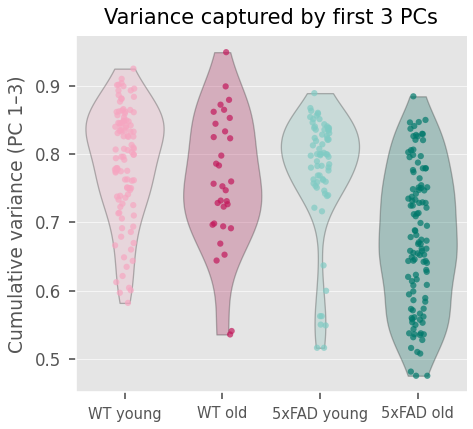

In [44]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(PlotStyle.HALF_WIDTH, 3.0))

sns.violinplot(
    data=df, x="group", y="cumvar_3", hue="group", order=GROUP_ORDER,
    palette=palette, inner=None, alpha=0.3, ax=ax, cut=0, legend=False,
)
sns.stripplot(
    data=df, x="group", y="cumvar_3", hue="group", order=GROUP_ORDER,
    palette=palette, size=3, alpha=0.7, jitter=True, ax=ax, legend=False,
)

ax.set_ylabel("Cumulative variance (PC 1–3)")
ax.set_xlabel("")
ax.set_xticks(range(len(GROUP_ORDER)))
ax.set_xticklabels([g.replace("_", " ") for g in GROUP_ORDER], fontsize=7)
ax.set_title("Variance captured by first 3 PCs")
plt.tight_layout()
fig.savefig(fig_path / "cumvar_3pcs_by_group.pdf")
plt.show()

### 3b — Mean scree curves by group

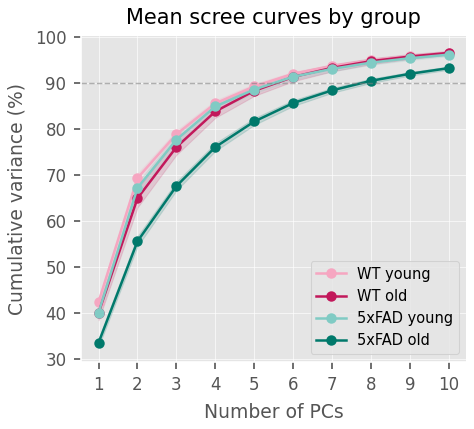

In [45]:
fig, ax = plt.subplots(figsize=(PlotStyle.HALF_WIDTH, 3.0))

x = np.arange(1, MAX_PCS + 1)
for group in GROUP_ORDER:
    mask = df["group"] == group
    var_mat = np.stack(df.loc[mask, "var_explained"].values)  # (n_recordings, MAX_PCS)
    cumvar = np.cumsum(var_mat, axis=1) * 100
    mean = cumvar.mean(axis=0)
    sem = cumvar.std(axis=0) / np.sqrt(cumvar.shape[0])

    ax.plot(x, mean, "o-", color=palette[group], markersize=4, label=group.replace("_", " "))
    ax.fill_between(x, mean - sem, mean + sem, color=palette[group], alpha=0.15)

ax.axhline(90, ls="--", color="grey", lw=0.7, alpha=0.6)
ax.set_xlabel("Number of PCs")
ax.set_ylabel("Cumulative variance (%)")
ax.set_title("Mean scree curves by group")
ax.set_xticks(x)
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(fig_path / "mean_scree_by_group.pdf")
plt.show()

### 3c — Variance in first 3 PCs by experiment type

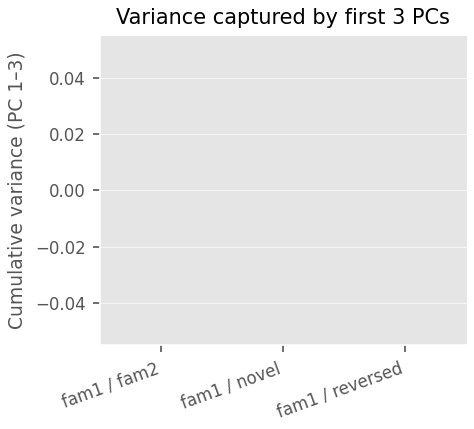

In [46]:
fig, ax = plt.subplots(figsize=(PlotStyle.HALF_WIDTH, 3.0))

sns.violinplot(
    data=df, x="exp_type", y="cumvar_3", hue="exp_type", order=EXPERIMENT_TYPE_ORDER,
    palette=EXPERIMENT_TYPE_COLORS, inner=None, alpha=0.3, ax=ax, cut=0, legend=False,
)
sns.stripplot(
    data=df, x="exp_type", y="cumvar_3", hue="exp_type", order=EXPERIMENT_TYPE_ORDER,
    palette=EXPERIMENT_TYPE_COLORS, size=3, alpha=0.7, jitter=True, ax=ax, legend=False,
)

ax.set_xticks(range(len(EXPERIMENT_TYPE_ORDER)))
ax.set_xticklabels(EXPERIMENT_TYPE_ORDER, rotation=20, ha="right")

ax.set_ylabel("Cumulative variance (PC 1–3)")
ax.set_xlabel("")
ax.set_title("Variance captured by first 3 PCs")
plt.tight_layout()
fig.savefig(fig_path / "cumvar_3pcs_by_experiment_type.pdf")
plt.show()